In [189]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

In [190]:
df_temp = pd.read_csv("..\\Data\\Tmean_obs.csv", parse_dates=True, skiprows = 26, delimiter="\\s+", header=None) 
df_temp.columns = ["date", "Tmean [C]",]
df_temp["date"] = pd.to_datetime(df_temp["date"], format="%Y%m%d")
df_temp.set_index("date", inplace=True)

df_prcp = pd.read_csv("..\\Data\\prcp_obs.csv", parse_dates=True, skiprows = 27, delimiter="\\s+", header=None)
df_prcp.columns = ["date", "precip [mm/day]"]
df_prcp["date"] = pd.to_datetime(df_prcp["date"], format="%Y%m%d")
df_prcp.set_index("date", inplace=True)

df_disc = pd.read_csv("..\\Data\\2.595.0-Vannføring-inst-v1.csv", parse_dates=True, skiprows = 1, delimiter=";", decimal=",")
df_disc.drop(columns=["Korrigert", "Kontrollert"], inplace=True)
df_disc.dropna(inplace=True)
df_disc.columns = ["date", "Q(m3/s)"]
df_disc.set_index(pd.to_datetime(pd.to_datetime(df_disc["date"]).dt.date), inplace=True)
df_disc.drop(columns=["date"], inplace=True)
df_disc = df_disc.resample("D").mean()

df = df_temp.join(df_prcp).join(df_disc)
# df.dropna(inplace=True)
display(df)

,Tmean [C],precip [mm/day],Q(m3/s)
date,,,
1920-01-01,-11.853330,1.414465,NaN
1920-01-02,-13.153330,0.208641,NaN
1920-01-03,-20.386670,0.000000,NaN
1920-01-04,-8.796666,0.000000,NaN
1920-01-05,-12.690000,0.000000,NaN
...,...,...,...
2025-10-27,-1.356667,0.000000,23.653758
2025-10-28,-4.233333,0.000000,22.214355
2025-10-29,-6.763333,0.852455,20.837645


In [191]:
### plot parameters ###
w_hist = 12 # width histogram
h_hist = 6  # height histogram

w_time = 15 # width time series
h_time = 5  # height time series

lw = 0.8 # line width
lc = 'black' # line color
ms = 7 # marker size
mc = 'red' # marker color
mt = 'x'
alpha = 0.5 # transparency

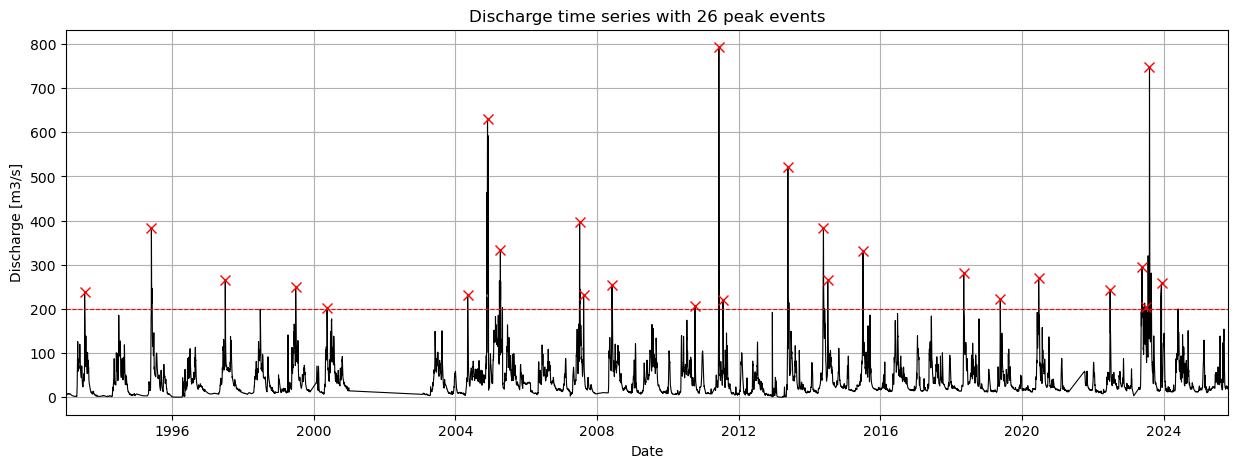

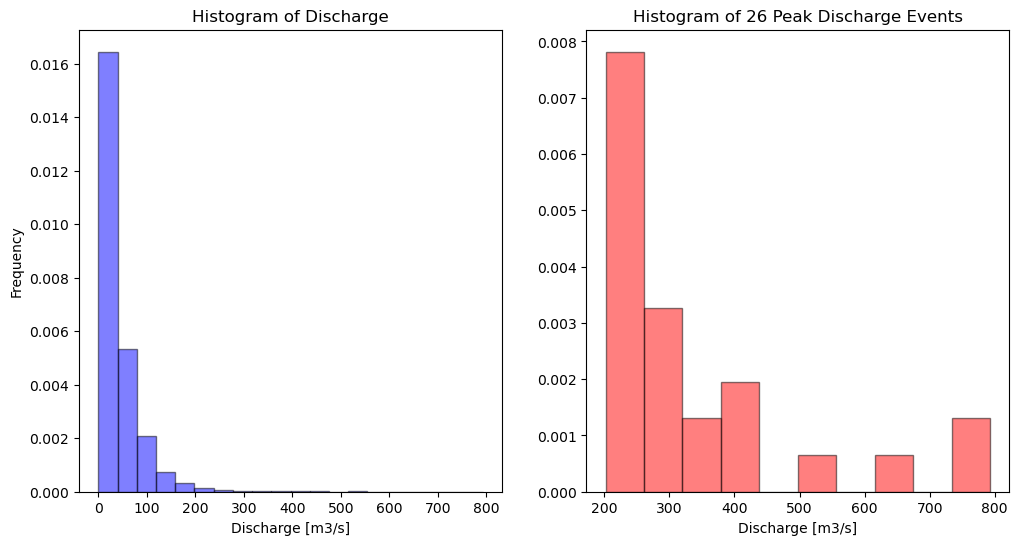

In [192]:
### discharge plottings ###
data = df.drop(columns=["Tmean [C]", "precip [mm/day]"])
data.dropna(inplace=True)
peaks, _ = find_peaks(data["Q(m3/s)"].values, height=200, distance=32)
exces = data.iloc[peaks]["Q(m3/s)"].values
dpeak = data.index[peaks]

# timeseries with peaks
fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.plot(data.index, data.values, color=lc, linewidth=lw)
ax.plot(dpeak, exces, marker=mt, color=mc, markersize=ms, linestyle='None')
ax.set_title(f"Discharge time series with {len(peaks)} peak events")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge [m3/s]")
ax.grid()
ax.set_xlim([data.index.min(), data.index.max()])
ax.hlines(200, data.index.min(), data.index.max(), color='red', linestyle='--', label='Peak Threshold (200 m3/s)', lw=lw)
plt.savefig("..\\Figures\\discharge_analysis_timeseries.png", dpi=300)

# histogram of peaks
fig, axes = plt.subplots(1, 2, figsize=(w_hist, h_hist))

axes[0].hist(data["Q(m3/s)"], bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title("Histogram of Discharge")
axes[0].set_xlabel("Discharge [m3/s]")
axes[0].set_ylabel("Frequency")

axes[1].set_title(f"Histogram of {len(peaks)} Peak Discharge Events")
axes[1].set_xlabel("Discharge [m3/s]")
axes[1].hist(exces, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
plt.savefig("..\\Figures\\discharge_analysis_hist.png", dpi=300)

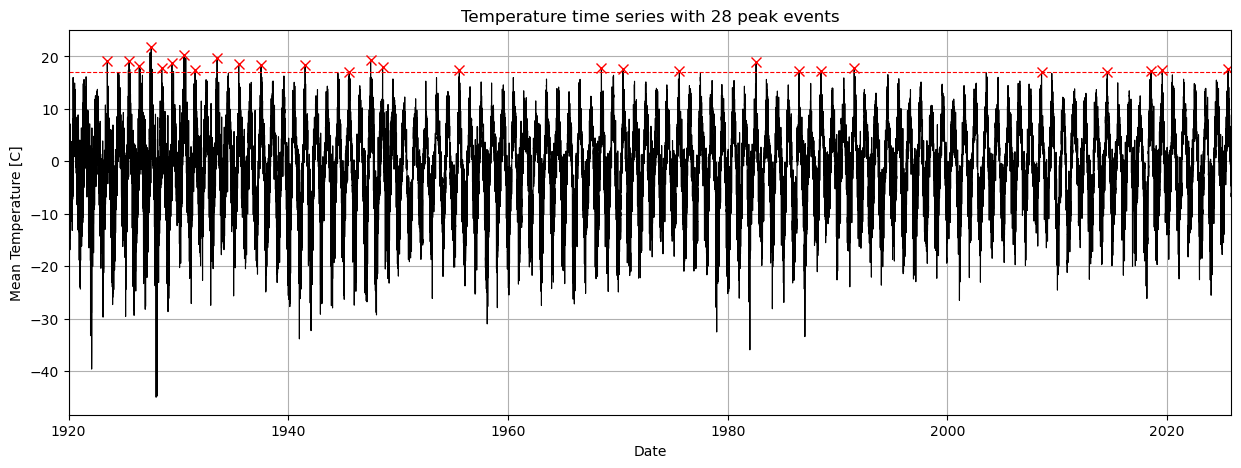

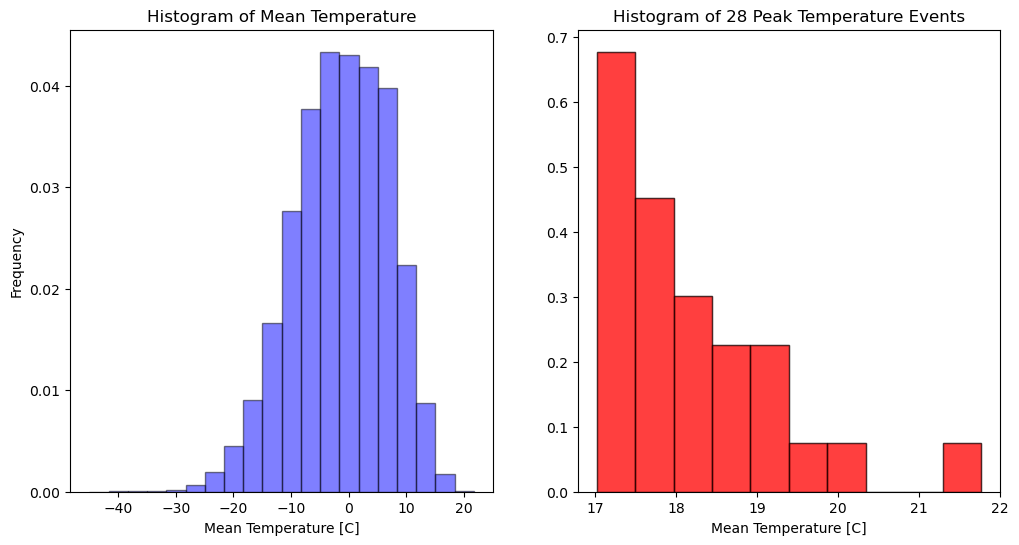

In [193]:
### temperature plottings ###
data = df.drop(columns=["precip [mm/day]", "Q(m3/s)"])
peaks, _ = find_peaks(data["Tmean [C]"].values, height=17, distance=300)
exces = data.iloc[peaks]["Tmean [C]"].values
dpeak = data.index[peaks]

# timeseries with peaks
fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.plot(data.index, data.values, color=lc, linewidth=lw)
ax.plot(dpeak, exces, marker=mt, color=mc, markersize=ms, linestyle='None')
ax.set_title(f"Temperature time series with {len(peaks)} peak events")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature [C]")
ax.grid()
ax.set_xlim([data.index.min(), data.index.max()])
ax.hlines(17, data.index.min(), data.index.max(), color='red', linestyle='--', label='Peak Threshold (17 C)', lw=lw)
plt.savefig("..\\Figures\\temperature_analysis_timeseries.png", dpi=300)

# histogram of peaks
fig, axes = plt.subplots(1, 2, figsize=(w_hist, h_hist))
axes[0].hist(data["Tmean [C]"], bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title("Histogram of Mean Temperature")
axes[0].set_xlabel("Mean Temperature [C]")
axes[0].set_ylabel("Frequency")
axes[1].set_title(f"Histogram of {len(peaks)} Peak Temperature Events")
axes[1].set_xlabel("Mean Temperature [C]")
axes[1].hist(exces, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)

axes[1].hist(exces, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
axes[1].set_xlabel("Mean Temperature [C]")
axes[1].set_title(f"Histogram of {len(peaks)} Peak Temperature Events")
plt.savefig("..\\Figures\\temperature_analysis_hist.png", dpi=300)

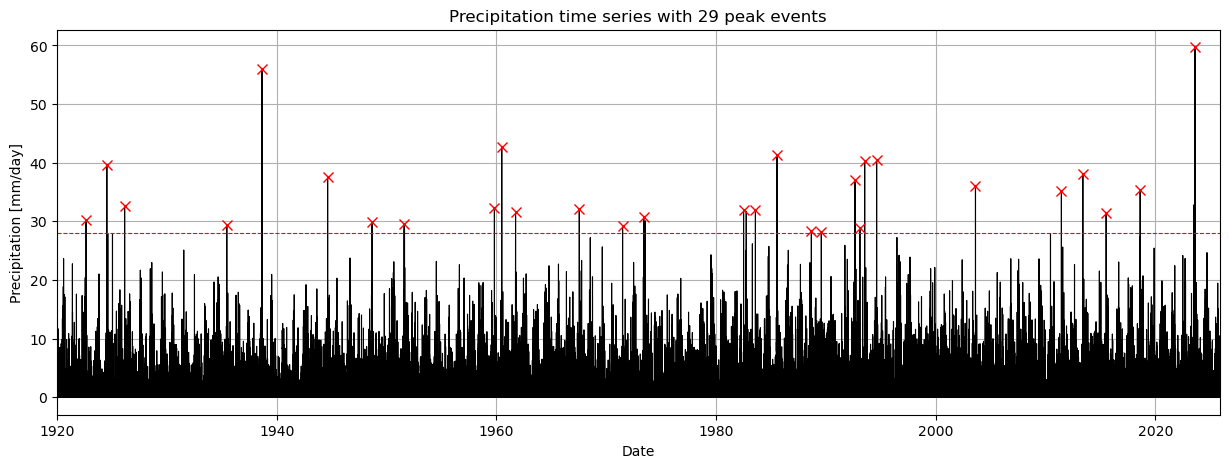

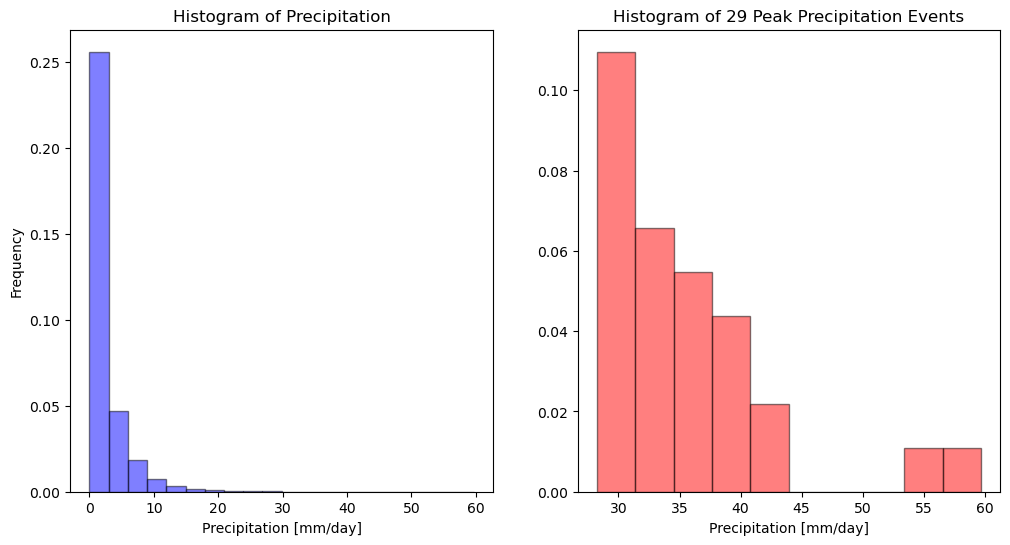

In [194]:
### precipitation plottings ###
thresh = 28

data = df.drop(columns=["Tmean [C]", "Q(m3/s)"])
peaks, _ = find_peaks(data["precip [mm/day]"].values, height=thresh, distance=100)
exces = data.iloc[peaks]["precip [mm/day]"].values
dpeak = data.index[peaks]

# timeseries with peaks
fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.plot(data.index, data.values, color=lc, linewidth=lw)
ax.plot(dpeak, exces, marker=mt, color=mc, markersize=ms, linestyle='None')
ax.set_title(f"Precipitation time series with {len(peaks)} peak events")
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation [mm/day]")
ax.grid()
ax.set_xlim([data.index.min(), data.index.max()])

ax.hlines(thresh, data.index.min(), data.index.max(), color='red', linestyle='--', label=f'Peak Threshold ({thresh} mm/day)', lw=lw)
plt.savefig("..\\Figures\\precipitation_analysis_timeseries.png", dpi=300)

# histogram of peaks
fig, axes = plt.subplots(1, 2, figsize=(w_hist, h_hist))
axes[0].hist(data["precip [mm/day]"], bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title("Histogram of Precipitation")
axes[0].set_xlabel("Precipitation [mm/day]")
axes[0].set_ylabel("Frequency")

axes[1].set_title(f"Histogram of {len(peaks)} Peak Precipitation Events")
axes[1].set_xlabel("Precipitation [mm/day]")
axes[1].hist(exces, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
plt.savefig("..\\Figures\\precipitation_analysis_hist.png", dpi=300)
